<a href="https://colab.research.google.com/github/siddhisalkar2005/CSL701-CE40_Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Siddhi Vitthal Salkar

Batch : CE3


Roll Number : CE40



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
# Task 1: Import Libraries and Load Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Breast Cancer dataset
df = pd.read_csv("brca.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Task 2: Explore the Dataset

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Check diagnosis class distribution
print("\nDiagnosis Class Distribution:")
print(df["y"].value_counts())

# Display class percentages
print("\nDiagnosis Class Percentage:")
print(df["y"].value_counts(normalize=True) * 100)

Dataset Shape: (569, 32)

Column Names:
['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se      

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Task 3: Preprocess and Scale Features

# Drop non-informative columns
X = df.drop(columns=["id", "diagnosis"], errors="ignore")

# Select only numerical features
X = X.select_dtypes(include=[np.number])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("Scaled Features:")
print(X_scaled.head())

# Display shape
print("\nScaled Data Shape:", X_scaled.shape)

Scaled Features:
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0   -1.729009      -0.166799       -1.147162         -0.185728    -0.251957   
1   -1.722921      -0.297446       -0.833008         -0.261106    -0.383638   
2   -1.716833      -1.313080       -1.593959         -1.302806    -1.083572   
3   -1.710745      -0.311646       -0.202373         -0.385500    -0.372831   
4   -1.704657      -1.684571       -0.570050         -1.658278    -1.288347   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0           0.101747           -0.436850         -0.278210   
1           0.792763            0.429422         -0.541362   
2           0.429819           -0.747086         -0.743748   
3          -0.464730           -1.263703         -0.793214   
4          -0.737294           -0.851130         -0.915500   

   x.concave_pts_mean  x.symmetry_mean  ...  x.radius_worst  x.texture_worst  \
0           -0.028609         0.267911  ...       -0.24

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Task 4: Construct Pairwise Distance Matrix & Graph

from scipy.spatial.distance import pdist, squareform

# Compute pairwise Euclidean distances
distance_matrix = squareform(pdist(X_scaled, metric="euclidean"))

# Display distance matrix shape
print("Distance Matrix Shape:", distance_matrix.shape)

# Create weighted complete graph
G = nx.Graph()

# Add all samples as nodes
G.add_nodes_from(range(len(X_scaled)))

# Add edges with distance as weight
for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G.add_edge(i, j, weight=distance_matrix[i, j])

print("Number of Nodes:", G.number_of_nodes())
print("Number of Edges:", G.number_of_edges())

Distance Matrix Shape: (569, 569)
Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Task 5: Compute the Minimum Spanning Tree (MST)

# Compute MST using NetworkX
mst = nx.minimum_spanning_tree(G, weight="weight")

# Display MST information
print("Number of Nodes in MST:", mst.number_of_nodes())
print("Number of Edges in MST:", mst.number_of_edges())

# Extract MST edges and weights
mst_edges = list(mst.edges(data=True))

print("\nFirst 10 MST Edges with Weights:")
for u, v, data in mst_edges[:10]:
    print(f"Node {u} -- Node {v} : Weight = {data['weight']:.4f}")

Number of Nodes in MST: 569
Number of Edges in MST: 568

First 10 MST Edges with Weights:
Node 0 -- Node 81 : Weight = 1.7591
Node 0 -- Node 108 : Weight = 2.2688
Node 1 -- Node 105 : Weight = 1.7773
Node 2 -- Node 70 : Weight = 2.2572
Node 2 -- Node 58 : Weight = 3.0227
Node 3 -- Node 170 : Weight = 2.5570
Node 4 -- Node 84 : Weight = 2.2201
Node 4 -- Node 114 : Weight = 2.3576
Node 5 -- Node 34 : Weight = 1.8237
Node 6 -- Node 29 : Weight = 2.0507


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Task 6: Implement Graph-Based Clustering (K=2)

# Sort MST edges by weight in descending order
sorted_edges = sorted(
    mst.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)

# Copy the MST
mst_clusters = mst.copy()

# Remove the largest edge
u, v, data = sorted_edges[0]
mst_clusters.remove_edge(u, v)

# Find the connected components
components = list(nx.connected_components(mst_clusters))

# Assign cluster labels
cluster_labels = np.zeros(len(X_scaled), dtype=int)

for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Display results
print("Number of Clusters:", len(components))

print("\nCluster Distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

print("\nFirst 20 Cluster Labels:")
print(cluster_labels[:20])

Number of Clusters: 2

Cluster Distribution:
0    567
1      2
Name: count, dtype: int64

First 20 Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Task 7: Evaluate MST Clustering Performance

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Get ground truth labels
y_true = df["y"].map({"B": 0, "M": 1})

# Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, cluster_labels)

# Calculate Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(y_true, cluster_labels)

# Calculate Normalized Mutual Information (NMI)
nmi_score = normalized_mutual_info_score(y_true, cluster_labels)

# Display results
print("MST Clustering Performance")
print("---------------------------")
print("Silhouette Score:", round(sil_score, 4))
print("Adjusted Rand Index (ARI):", round(ari_score, 4))
print("Normalized Mutual Information (NMI):", round(nmi_score, 4))

MST Clustering Performance
---------------------------
Silhouette Score: 0.6547
Adjusted Rand Index (ARI): 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

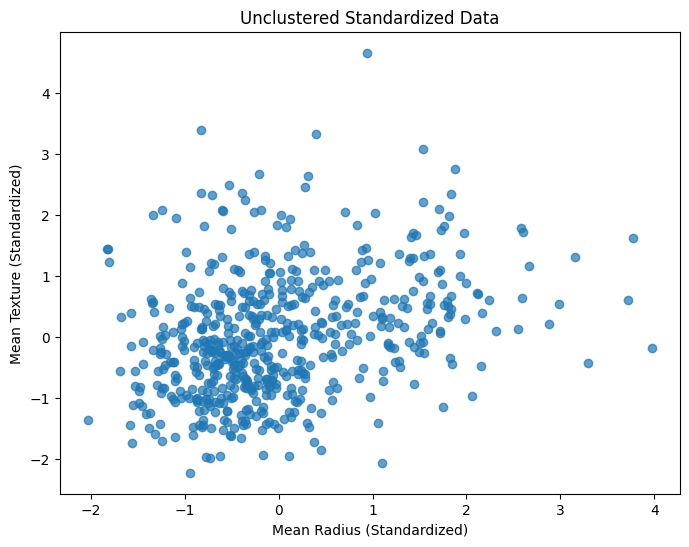

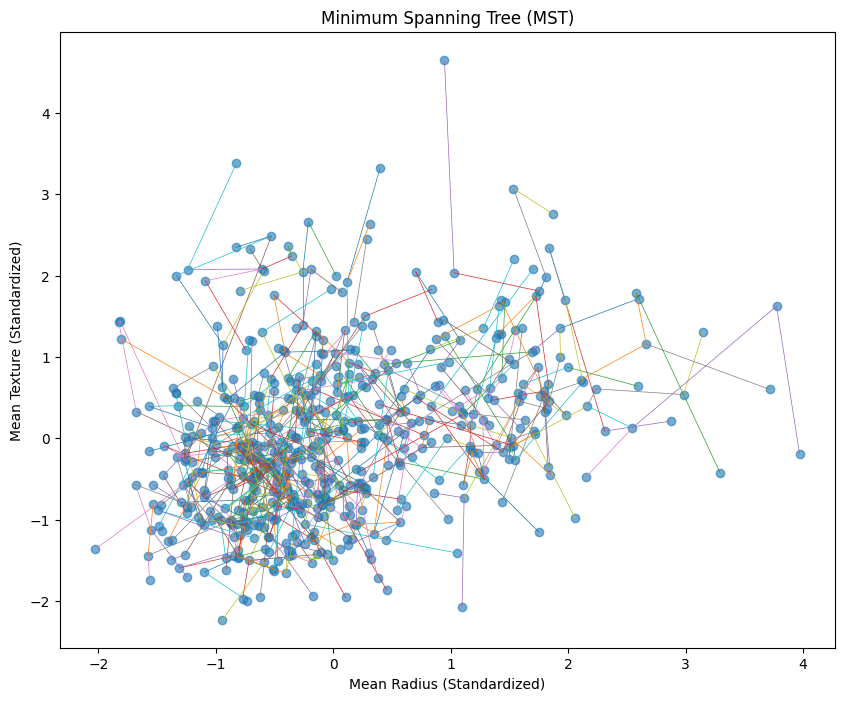

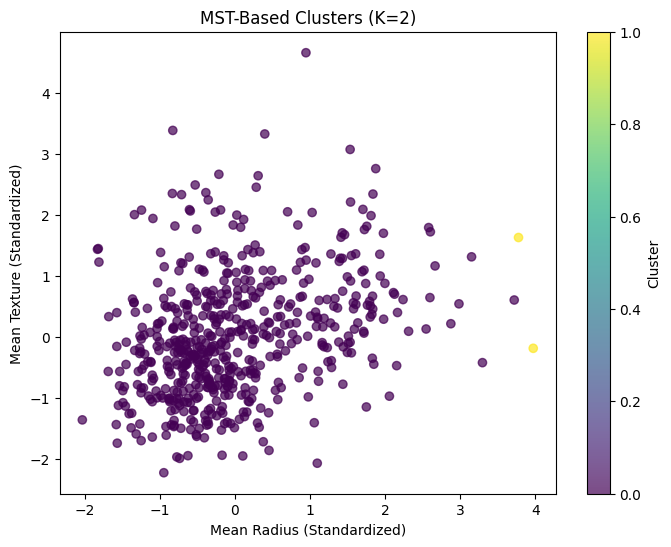

In [ ]:
# Task 8: Visualize MST and Graph-Based Clusters

# Select two representative features
feature_x = "x.radius_mean"
feature_y = "x.texture_mean"

# Get feature indices
x_idx = list(X.columns).index(feature_x)
y_idx = list(X.columns).index(feature_y)

# Extract the two standardized features
x = X_scaled.iloc[:, x_idx]
y = X_scaled.iloc[:, y_idx]


# --------------------------------------------------
# Plot 1: Unclustered Standardized Data
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(x, y, alpha=0.7)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Unclustered Standardized Data")

plt.show()


# --------------------------------------------------
# Plot 2: Minimum Spanning Tree (MST)
# --------------------------------------------------

plt.figure(figsize=(10, 8))

# Plot data points
plt.scatter(x, y, alpha=0.6)

# Plot MST edges
for u, v, data in mst.edges(data=True):
    plt.plot(
        [x.iloc[u], x.iloc[v]],
        [y.iloc[u], y.iloc[v]],
        linewidth=0.5
    )

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("Minimum Spanning Tree (MST)")

plt.show()


# --------------------------------------------------
# Plot 3: Final Graph-Based Clusters
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    c=cluster_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Mean Radius (Standardized)")
plt.ylabel("Mean Texture (Standardized)")
plt.title("MST-Based Clusters (K=2)")

plt.colorbar(label="Cluster")

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.